<a href="https://colab.research.google.com/github/abhistacodes/colab-notebooks/blob/miss/fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')

print(device)
from google.colab import files

uploaded = files.upload()

cuda


Saving fmnist_small.csv to fmnist_small (2).csv


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [ ]:
# the dataset has 785 columns, col0= labels= 10 classes
df = pd.read_csv('fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [ ]:
#6000 images(rows = examples)
#784 cols= 28x28 pixels per image
df.shape

(6000, 785)

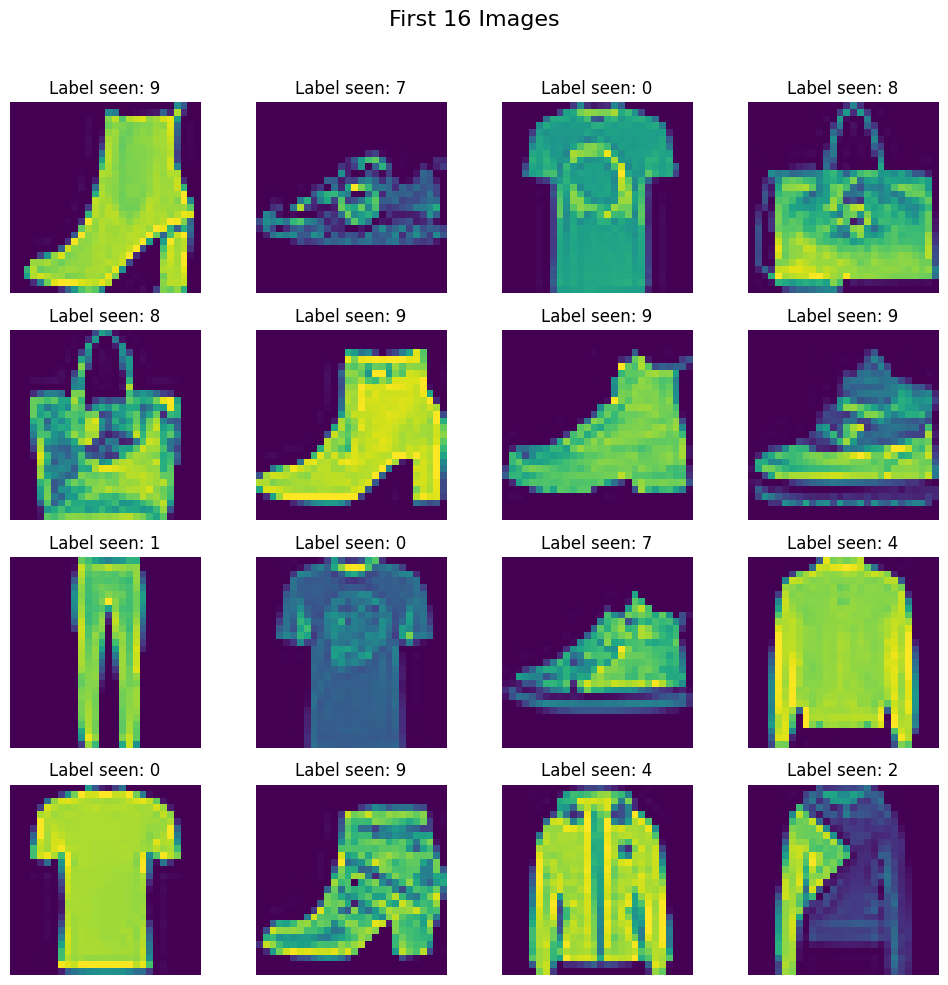

In [ ]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28,28)  # 784 rows->Reshape to 28x28, for ith image and col(1-784)
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look, axes determine the scales
    ax.set_title(f"Label seen: {df.iloc[i, 0]}")  # Show the label, as in the label column = col0 for ith image

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

In [ ]:
#input = X = pixel values in col0-784
#output = Y = labels in col=0
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

1. train_test_split: This is a function from the sklearn.model_selection module. Its purpose is to divide your input features (X) and corresponding target labels (y) into two subsets: one for training your machine learning model and one for evaluating its performance.
2. X: This represents the feature data (in this case, the pixel values of the images). It's the input to the model.
3. y: This represents the target labels (in this case, the fashion item labels). It's what the model will try to predict.
4. test_size=0.2: This parameter specifies the proportion of the dataset to be used for the test set. Here, 0.2 means that 20% of the data will be allocated to the test set, and the remaining 80% will be used for the training set.
5. random_state=42: This parameter is used for reproducibility. When data is split randomly, setting a random_state to an integer (like 42) ensures that the same random split is generated every time when code is run. If not set, a different train/test split is obtained each time, which can make debugging and comparing model performances difficult.
After this line executes, four new variables:

X_train: The features used for training the model.

X_test: The features used for evaluating the model.

y_train: The corresponding labels for the training features.

y_test: The corresponding labels for the test features.

In [ ]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# scaling the feautures because some values are more than 100, hence to make all values between 0-1
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
#creating CustomDataset class
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.features = torch.tensor(X, dtype=torch.float32)
        self.labels = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [ ]:
#creating train dataset object of CustomDataset class
train_dataset = CustomDataset(X_train, y_train)
len(train_dataset) # should be (1-test_size)*(df.shape[0])

4800

In [ ]:
#creating test dataset object of CustomDataset class
test_dataset = CustomDataset(X_test, y_test)
len(test_dataset) # should be (test_size)*(df.shape[0])

1200

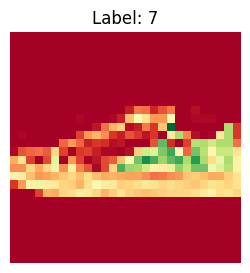

In [ ]:
# Display the 1st image of the train dataset
image_tensor, label = train_dataset[0]

# Convert the tensor to a NumPy array and reshape it to 28x28
img = image_tensor.numpy().reshape(28, 28)

plt.figure(figsize=(3,3))
plt.imshow(img, cmap='RdYlGn') # Use 'gray' colormap for single channel images
plt.title(f'Label: {label.item()}') # .item() to get scalar value from tensor
plt.axis('off')
plt.show()

In [ ]:
#creating DataLoader objects
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

Now the neural network is considered to have:
1. 785 (784pixels + 1label) inputs in first layer
2. leads to 128 outputs (= hidden linear layer1) with activation function = ReLU
3. which (128) is again input of 3rd linear layer (= hidden layer2) with activation function = ReLU
4. which gives 64 outputs and this is again input
5. which finally gives output in 10 classes

In [ ]:
#define NN class
class MyNN(nn.Module):

  #constructor
  def __init__(self, num_features):
    super(MyNN, self).__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)
    )


  def forward(self, x):
    return self.model(x)

In [ ]:
#define paramaters
epochs = 10
learning_rate = 0.1

In [ ]:
#instantiate the model, create object of MyNN class
model = MyNN(X_train.shape[1]) #X_train.shape[1] = num(columns) = 785
model = model.to(device)
#loss function
criterion = nn.CrossEntropyLoss()

#optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
#training loop
for epoch in range(epochs):

  total_epoch_loss = 0
  for batch_features, batch_labels in train_loader:

    #move data to gpu
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    #forward pass
    outputs = model(batch_features)


    #calculate loss
    loss = criterion(outputs, batch_labels)

    #backward pass
    optimizer.zero_grad() #gradients set to 0
    loss.backward() #gradients calculated

    #upgrade grads
    optimizer.step()

    total_epoch_loss += loss.item()

  avg_epoch_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch {epoch+1}, Loss: {avg_epoch_loss}')

Epoch 1, Loss: 1.3216368587811789
Epoch 2, Loss: 0.779336541891098
Epoch 3, Loss: 0.6427524608373641
Epoch 4, Loss: 0.5751657414436341
Epoch 5, Loss: 0.5278772541880608
Epoch 6, Loss: 0.49531100074450174
Epoch 7, Loss: 0.46192684868971506
Epoch 8, Loss: 0.4355265040695667
Epoch 9, Loss: 0.41890643616517387
Epoch 10, Loss: 0.39741520086924237


In [ ]:
#model evaluation

#model.eval() puts the model in evaluation mode
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

For each cycle of evaluation, a certain batch of images( say 32 images per batch) is sent to the model to predict. For each such cycle, the model outputs a tensor if size 32x10 with each of 10 columns predicting probability of that image belonging to that class. The max value among 10 values is the class of that image

In [ ]:
#evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    #move data to gpu
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)


0.8325


In [ ]:
len(test_loader)

38